In [2]:
from datasets import load_dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

train_dataset = load_dataset("cardiffnlp/tweet_eval", 'sentiment', split='train')
test_dataset = load_dataset("cardiffnlp/tweet_eval", 'sentiment', split='test')
val_dataset = load_dataset("cardiffnlp/tweet_eval", 'sentiment', split='validation')

columns_to_drop = [col for col in train_dataset.column_names if col not in ['text', 'label']]

# Tokenize
tokenizer = RobertaTokenizer.from_pretrained('FacebookAI/roberta-base')
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding='max_length', max_length=128)

/home/lava/Documents/ML/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
type(train_dataset['label'][0])

int

In [4]:
train_data = train_dataset.map(tokenize, batched=True)
val_data = val_dataset.map(tokenize, batched=True)
test_data = test_dataset.map(tokenize, batched=True)

columns_to_keep = ['input_ids', 'attention_mask', 'label']
train_data.set_format(type='torch', columns=columns_to_keep)
val_data.set_format(type='torch', columns=columns_to_keep)
test_data.set_format(type='torch', columns=columns_to_keep)

In [5]:
test_data.info

DatasetInfo(description='', citation='', homepage='', license='', features={'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive']), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='tweet_eval', config_name='sentiment', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=5430824, num_examples=45615, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval'), 'test': SplitInfo(name='test', num_bytes=1281076, num_examples=12284, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval'), 'validation': SplitInfo(name='validation', num_bytes=239334, num_examples=2000, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval')}, download_checksums={'hf://datasets/cardiffnlp/tweet_eval@b3a375baf0f409c77e6bc7aa35102b7b3534f8be/sentiment/train-00000-of-00001.parquet': {'num_bytes': 3781982, 'c

In [6]:
import optuna
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# This guarantees every trial starts with a fresh model
def model_init():
    return RobertaForSequenceClassification.from_pretrained('FacebookAI/roberta-base', num_labels=3, problem_type="single_label_classification")

# 2. Define the baseline arguments (things that won't change)
training_args = TrainingArguments(
    output_dir="./tuning_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    bf16=True, 
    dataloader_num_workers=8,
    logging_strategy="steps",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_recall",
    greater_is_better=True
)

def compute_metrics(pred):
    labels = pred.label_ids
    
    # Get the highest predicted class index
    preds = pred.predictions.argmax(-1)
    
    # Calculate each metric individually using 'macro' average
    precision = precision_score(labels, preds, average='macro')
    recall = recall_score(labels, preds, average='macro')
    f1 = f1_score(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    
    # Return the dictionary for the Trainer
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32, 64]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.0, 0.2),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5)
    }

def compute_objective(metrics):
    return metrics["eval_recall"]

best_trial = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=20,
    compute_objective=compute_objective
)

print(f"Best parameters found: {best_trial.hyperparameters}")

final_training_args = TrainingArguments(
    output_dir="./final_roberta_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    bf16=True,
    dataloader_num_workers=8,
    learning_rate=best_trial.hyperparameters["learning_rate"],
    per_device_train_batch_size=best_trial.hyperparameters["per_device_train_batch_size"],
    weight_decay=best_trial.hyperparameters["weight_decay"],
    warmup_ratio=best_trial.hyperparameters["warmup_ratio"],
    num_train_epochs=best_trial.hyperparameters["num_train_epochs"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_recall",
    greater_is_better=True
)

final_trainer = Trainer(
    model_init=model_init,
    args=final_training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

final_trainer.train()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1283.96it/s]
RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-04-29 20:42:35,103] A ne

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.631551,0.596654,0.739000,0.725276,0.743064,0.718471
2,0.488788,0.589745,0.751000,0.736712,0.730655,0.744587


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.593717,0.587324,0.745500,0.729080,0.729432,0.730330
2,0.497708,0.588135,0.750000,0.736428,0.729536,0.745944


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

...

Best parameters found: {'learning_rate': 1.3807640596902054e-05, 'per_device_train_batch_size': 32, 'weight_decay': 0.05097337783963144, 'warmup_ratio': 0.03532027077079778, 'num_train_epochs': 3}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5904.77it/s]
RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.625399,0.601442,0.727500,0.709099,0.729347,0.701267
2,0.508829,0.597314,0.740500,0.717734,0.731356,0.708689
3,0.444538,0.626549,0.749000,0.733705,0.726627,0.743948


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=4278, training_loss=0.5431054031921358, metrics={'train_runtime': 428.0944, 'train_samples_per_second': 319.661, 'train_steps_per_second': 9.993, 'total_flos': 9001438912247040.0, 'train_loss': 0.5431054031921358, 'epoch': 3.0})

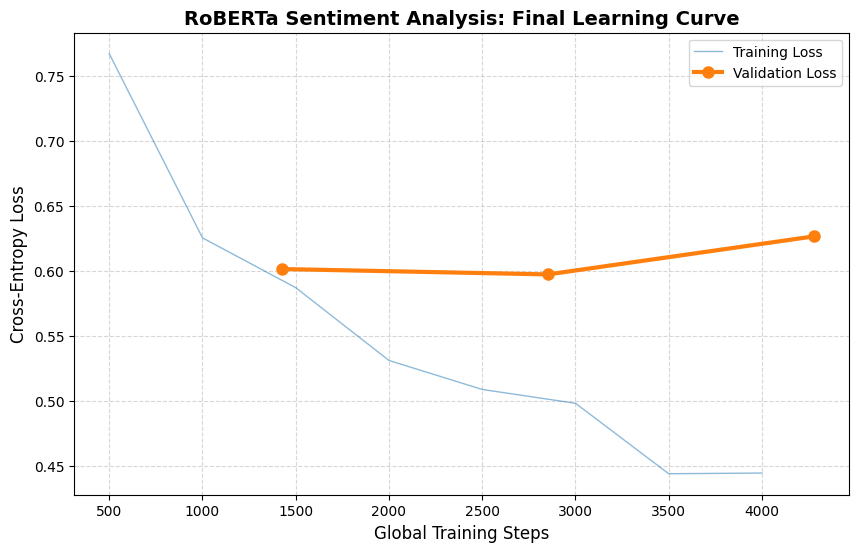

In [7]:
import matplotlib.pyplot as plt

# Get the logs
history = final_trainer.state.log_history

# Initialize our lists
train_loss = []
train_steps = []
eval_loss = []
eval_steps = []

for entry in history:
    # If the entry has 'loss', it's a training step update
    if 'loss' in entry:
        train_loss.append(entry['loss'])
        train_steps.append(entry['step'])
    # If the entry has 'eval_loss', it's an epoch milestone
    elif 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_steps.append(entry['step'])

# PLOTTING
plt.figure(figsize=(10, 6))

# The Training line (Detailed)
if train_loss:
    plt.plot(train_steps, train_loss, label='Training Loss', color='#1f77b4', alpha=0.5, linewidth=1)
else:
    print("Warning: No Training Loss steps found. Did you set logging_steps=10?")

# The Validation line (Milestones)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='#ff7f0e', linewidth=3, marker='o', markersize=8)

plt.title('RoBERTa Sentiment Analysis: Final Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Global Training Steps', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
from sklearn.metrics import classification_report
print("\n--- Final Test Set Evaluation ---")
test_results = final_trainer.predict(test_data)

y_true = test_results.label_ids
y_pred = test_results.predictions.argmax(-1)

# Assuming standard TwitterEval mapping: 0=Negative, 1=Neutral, 2=Positive
target_names = ['Negative', 'Neutral', 'Positive'] 

report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


--- Final Test Set Evaluation ---


              precision    recall  f1-score   support

    Negative     0.7116    0.7777    0.7432      3972
     Neutral     0.7553    0.6436    0.6950      5937
    Positive     0.6404    0.7777    0.7024      2375

    accuracy                         0.7129     12284
   macro avg     0.7024    0.7330    0.7135     12284
weighted avg     0.7190    0.7129    0.7120     12284



In [11]:
model_dir = "./roberta_model"
final_trainer.save_model(model_dir)
tokenizer.save_pretrained(model_dir)

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.28s/it]


('./roberta_model/tokenizer_config.json', './roberta_model/tokenizer.json')

In [12]:
print(f"Best hyperparameters:")

# Loop through the dictionary and print them cleanly
for param_name, value in best_trial.hyperparameters.items():
    print(f"- {param_name}: {value}")

Best hyperparameters:
- learning_rate: 1.3807640596902054e-05
- per_device_train_batch_size: 32
- weight_decay: 0.05097337783963144
- warmup_ratio: 0.03532027077079778
- num_train_epochs: 3


In [ ]:
import json
report_dict = classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)
results = {
    "best_cv_recall_score": best_trial.objective,
    "best_parameters": {
        "learning_rate": best_trial.hyperparameters["learning_rate"],
        "per_device_train_batch_size": best_trial.hyperparameters["per_device_train_batch_size"],
        "weight_decay": best_trial.hyperparameters["weight_decay"],
        "warmup_ratio": best_trial.hyperparameters["warmup_ratio"],
        "num_train_epochs": best_trial.hyperparameters["num_train_epochs"]
    },
    "classification_report": {
        "negative": {
            "precision": report_dict["Negative"]["precision"],
            "recall": report_dict["Negative"]["recall"],
            "f1-score": report_dict["Negative"]["f1-score"],
            "support": report_dict["Negative"]["support"]
        },
        "neutral": {
            "precision": report_dict["Neutral"]["precision"],
            "recall": report_dict["Neutral"]["recall"],
            "f1-score": report_dict["Neutral"]["f1-score"],
            "support": report_dict["Neutral"]["support"]
        },
        "positive": {
            "precision": report_dict["Positive"]["precision"],
            "recall": report_dict["Positive"]["recall"],
            "f1-score": report_dict["Positive"]["f1-score"],
            "support": report_dict["Positive"]["support"]
        },
        "accuracy": report_dict["accuracy"],
        "macro avg": {
            "precision": report_dict["macro avg"]["precision"],
            "recall": report_dict["macro avg"]["recall"],
            "f1-score": report_dict["macro avg"]["f1-score"],
            "support": report_dict["macro avg"]["support"]
        },
        "weighted avg": {
            "precision": report_dict["weighted avg"]["precision"],
            "recall": report_dict["weighted avg"]["recall"],
            "f1-score": report_dict["weighted avg"]["f1-score"],
            "support": report_dict["weighted avg"]["support"]
        }
    }
}
print(json.dumps(results, indent=4))
with open("../model_results/roberta_search_results.json", "w") as f:
    json.dump(results, f, indent=4)

{
    "best_cv_recall_score": 0.7496032448564094,
    "best_parameters": {
        "learning_rate": 1.3807640596902054e-05,
        "per_device_train_batch_size": 32,
        "weight_decay": 0.05097337783963144,
        "warmup_ratio": 0.03532027077079778,
        "num_train_epochs": 3
    },
    "classification_report": {
        "negative": {
            "precision": 0.7115871918912693,
            "recall": 0.777693856998993,
            "f1-score": 0.7431733429568146,
            "support": 3972.0
        },
        "neutral": {
            "precision": 0.7552876062462938,
            "recall": 0.6435910392454102,
            "f1-score": 0.6949799927246272,
            "support": 5937.0
        },
        "positive": {
            "precision": 0.6404299583911235,
            "recall": 0.7776842105263158,
            "f1-score": 0.702414907777144,
            "support": 2375.0
        },
        "accuracy": 0.7128785411917942,
        "macro avg": {
            "precision": 0.702434